grafico mle fidelity classica/quantum vs N

grafico limite MLE: tempo computazione vs N qubit

# Import

In [11]:
# general import: 
import sys
import time
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [13]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
# from vae import *
from plots import *
from utils import *
from mle import *

# GHZ3

In [14]:
def generate_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

In [15]:
def mle_fidelities(samples, rho_true, p_exact, N):
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc    = classical_fidelity(p_exact, p_mle)
    fq    = quantum_fidelity(rho_true, rho_mle)

    return float(fc), float(fq)

In [16]:
N = 3
qc = create_ghz_state(N)
rho_true = DensityMatrix(qc)
p_exact = povm_probability(rho_true.data, N)

n_sample tested in [100, 200, 500, 1000, 5000, 10000]

In [29]:
B = 50           
n_samples = 10000

rows = []
for b in range(B):
    samples = generate_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fc_toy, fq_toy = mle_fidelities(samples, rho_true, p_exact, N)                                                  

    rows.append(dict(method='MLE', b=b, N=n_samples, F_c=fc_toy, F_q=fq_toy))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_c: {fc_toy:.4f} \t F_q: {fq_toy:.4f}")

df = pd.DataFrame(rows)
df.to_csv(f'MLE_analysis/MLE_results_run_N{n_samples}_B{B}_ghz.csv', index=False)
print("\n Saved!\t N_rows:", len(df))

1/50  F_c: 0.9997 	 F_q: 0.9604
2/50  F_c: 0.9998 	 F_q: 0.9694
3/50  F_c: 0.9996 	 F_q: 0.9586
4/50  F_c: 0.9996 	 F_q: 0.9548
5/50  F_c: 0.9997 	 F_q: 0.9614
6/50  F_c: 0.9994 	 F_q: 0.9421
7/50  F_c: 0.9997 	 F_q: 0.9588
8/50  F_c: 0.9998 	 F_q: 0.9624
9/50  F_c: 0.9995 	 F_q: 0.9526
10/50  F_c: 0.9998 	 F_q: 0.9666
11/50  F_c: 0.9996 	 F_q: 0.9518
12/50  F_c: 0.9997 	 F_q: 0.9581
13/50  F_c: 0.9996 	 F_q: 0.9534
14/50  F_c: 0.9995 	 F_q: 0.9433
15/50  F_c: 0.9997 	 F_q: 0.9635
16/50  F_c: 0.9996 	 F_q: 0.9533
17/50  F_c: 0.9997 	 F_q: 0.9510
18/50  F_c: 0.9997 	 F_q: 0.9773
19/50  F_c: 0.9996 	 F_q: 0.9575
20/50  F_c: 0.9997 	 F_q: 0.9648
21/50  F_c: 0.9997 	 F_q: 0.9598
22/50  F_c: 0.9997 	 F_q: 0.9551
23/50  F_c: 0.9997 	 F_q: 0.9496
24/50  F_c: 0.9996 	 F_q: 0.9684
25/50  F_c: 0.9996 	 F_q: 0.9645
26/50  F_c: 0.9997 	 F_q: 0.9747
27/50  F_c: 0.9998 	 F_q: 0.9734
28/50  F_c: 0.9998 	 F_q: 0.9641
29/50  F_c: 0.9997 	 F_q: 0.9578
30/50  F_c: 0.9996 	 F_q: 0.9557
31/50  F_c: 0.9997 

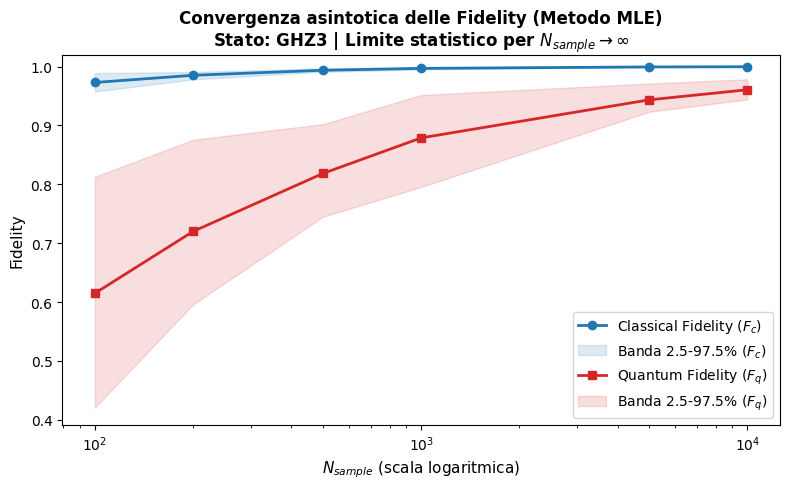

In [8]:
# grafico da riveder rispetto a stile altri grafici
import glob

# 1. Caricamento e preparazione dei dati (cella autosufficiente)
paths = sorted(glob.glob("MLE_analysis/MLE_results_run_N*_B50_ghz.csv"))
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
df_cmp = df_cmp.rename(columns={'N': 'N_sample'})

# Isiliamo solo il metodo MLE (l'unico ad avere sia F_c che F_q)
df_mle = df_cmp[df_cmp.method == 'MLE']

# 2. Configurazione dello stile del grafico
# sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

# Raggruppiamo per N_sample per estrarre le statistiche di F_c e F_q
g_fc = df_mle.groupby('N_sample')['F_c']
g_fq = df_mle.groupby('N_sample')['F_q']

# I valori di N_sample saranno l'asse X
n_values = g_fc.mean().index

# 3. Tracciamento della Classical Fidelity (F_c)
ax.plot(n_values, g_fc.mean().values, 'o-', color='C0', linewidth=2, label=r'Classical Fidelity ($F_c$)')
ax.fill_between(n_values, 
                g_fc.quantile(0.025).values, 
                g_fc.quantile(0.975).values, 
                color='C0', alpha=0.15, label='Banda 2.5-97.5% ($F_c$)')

# 4. Tracciamento della Quantum Fidelity (F_q)
ax.plot(n_values, g_fq.mean().values, 's-', color='C3', linewidth=2, label=r'Quantum Fidelity ($F_q$)')
ax.fill_between(n_values, 
                g_fq.quantile(0.025).values, 
                g_fq.quantile(0.975).values, 
                color='C3', alpha=0.15, label='Banda 2.5-97.5% ($F_q$)')

# 5. Personalizzazione degli assi e dei titoli
ax.set_xscale('log')
ax.set_xlabel(r"$N_{sample}$ (scala logaritmica)", fontsize=11)
ax.set_ylabel("Fidelity", fontsize=11)
ax.set_title("Convergenza asintotica delle Fidelity (Metodo MLE)\nStato: GHZ3 | Limite statistico per $N_{sample} \\rightarrow \\infty$", 
             fontsize=12, fontweight='bold')

# Limite superiore leggermente sopra 1 per evitare che le linee tocchino il bordo del grafico
ax.set_ylim(None, 1.02) 

# Posizioniamo la legenda in basso a destra dove c'è più spazio libero
ax.legend(loc='lower right', frameon=True)

# Ottimizzazione del layout e visualizzazione
fig.tight_layout()
plt.show()

# Limits

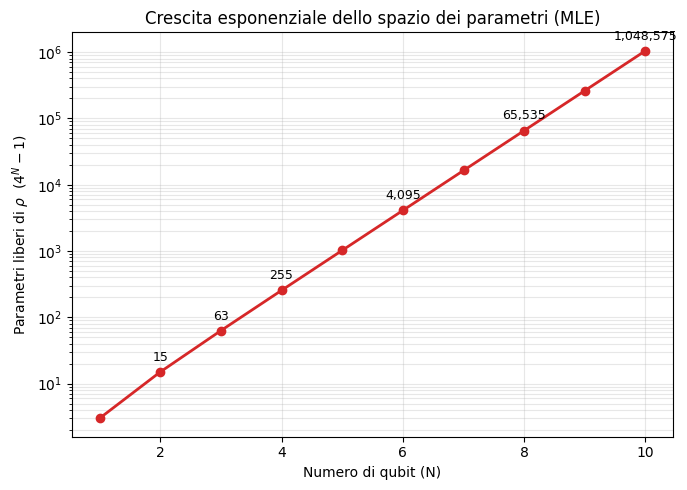

 N qubit |    dim rho |     N params
------------------------------------
       1 | 2x2      |            3
       2 | 4x4      |           15
       3 | 8x8      |           63
       4 | 16x16     |          255
       5 | 32x32     |        1,023
       6 | 64x64     |        4,095
       7 | 128x128    |       16,383
       8 | 256x256    |       65,535
       9 | 512x512    |      262,143
      10 | 1024x1024   |    1,048,575


In [9]:
# grafico N params da minimizzare con Minuit vs N qubit --> scala esponenzialmente
# inoltre, costo per ricostruire rho ogni volta tramite nll --> cholesky
 
n_qubits = np.arange(1, 11)          # da 1 a 10 qubit
n_params = 4**n_qubits - 1           # parametri reali liberi di rho
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_qubits, n_params, marker='o', linewidth=2, color='#d62728')
ax.set_yscale('log')
ax.set_xlabel('Numero di qubit (N)')
ax.set_ylabel(r'Parametri liberi di $\rho$  ($4^N - 1$)')
ax.set_title('Crescita esponenziale dello spazio dei parametri (MLE)')
ax.grid(True, which='both', alpha=0.3)
 
# annota i valori chiave
for n in [2, 3, 4, 6, 8, 10]:
    ax.annotate(f'{4**n - 1:,}', xy=(n, 4**n - 1),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9)
 
plt.tight_layout()
# plt.savefig('n_qubit_vs_n_params.png', dpi=150)
plt.show()
 
# tabella riassuntiva
print(f"{'N qubit':>8} | {'dim rho':>10} | {'N params':>12}")
print("-" * 36)
for n in n_qubits:
    print(f"{n:>8} | {2**n}x{2**n:<6} | {4**n - 1:>12,}")
 
 


In [17]:
import time
 
# -----------------------------------------------------------------------------
# Assumendo che tu abbia gia' definite le funzioni:
#   make_nll(samples, N), rho_to_params(rho, N), params_to_rho(params, N),
#   povm_probability(rho, N), classical_fidelity(p_exact, p_model),
#   prepare_ghz(N) -> rho_true, generate_samples(rho_true, N_sample, N) -> samples
# -----------------------------------------------------------------------------
 
def fit_mle_timed(p_exact, samples, N):
    """
    Wrapper della tua fit_mle che misura anche il tempo di convergenza.
    Riusa esattamente la stessa logica della tua funzione originale.
    """
    nll = make_nll(samples, N)
 
    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)
 
    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
 
    t0 = time.perf_counter()
    m.migrad()
    if not m.valid:
        m.migrad()
    elapsed = time.perf_counter() - t0
 
    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc = classical_fidelity(p_exact, p_mle)
 
    return float(fc), elapsed, m.valid
 

In [19]:
# 2, 3, 4 ca 3 min e 30
# -----------------------------------------------------------------------------
# Esecuzione: un solo dataset per qubit (no statistica qui, solo trend)
# Attenzione: a N=4 ci si aspetta gia' ~5 minuti; non andare oltre senza
# prima stimare il tempo totale.
# -----------------------------------------------------------------------------
qubit_range = [2, 3, 4]          # estendi con cautela, es. aggiungendo 5 solo se hai tempo
N_SAMPLE = 500                    # fissato, coerente con il resto dell'analisi
 
results_time = []
 
for N in qubit_range:
    print(f"--- N = {N} qubit ---")
 
    qc = create_ghz_state(N)                          # tua funzione di preparazione stato
    rho_true = DensityMatrix(qc)
    p_exact = povm_probability(rho_true.data, N)
    samples = generate_dataset(p_exact, seed_data=42, n_samples=N_SAMPLE)   # tua funzione di sampling
 
    fc, elapsed, valid = fit_mle_timed(p_exact, samples, N)
 
    print(f"  F_c = {fc:.4f}   tempo = {elapsed:.2f}s   convergenza valida = {valid}")
    results_time.append({'N_qubit': N, 'F_c': fc, 'time_s': elapsed, 'valid': valid})
 
import pandas as pd
df_time = pd.DataFrame(results_time)
print(df_time)


--- N = 2 qubit ---
  F_c = 0.9978   tempo = 0.38s   convergenza valida = True
--- N = 3 qubit ---
  F_c = 0.9924   tempo = 10.44s   convergenza valida = True
--- N = 4 qubit ---
  F_c = 0.9821   tempo = 311.32s   convergenza valida = True
   N_qubit       F_c      time_s  valid
0        2  0.997780    0.377046   True
1        3  0.992438   10.444609   True
2        4  0.982129  311.322883   True


In [21]:
df_time.to_csv(f'MLE_analysis/MLE_time.csv', index=False)
print("Saved! \t N_rows :", len(df_time))

Saved! 	 N_rows : 3


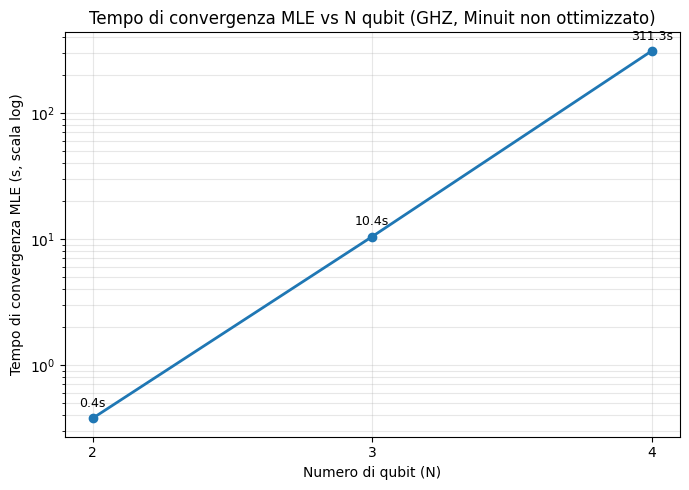

In [22]:
# -----------------------------------------------------------------------------
# Plot tempo di convergenza vs N_qubit
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_time['N_qubit'], df_time['time_s'], marker='o',
        linewidth=2, color='#1f77b4')
ax.set_yscale('log')
ax.set_xlabel('Numero di qubit (N)')
ax.set_ylabel('Tempo di convergenza MLE (s, scala log)')
ax.set_title('Tempo di convergenza MLE vs N qubit (GHZ, Minuit non ottimizzato)')
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(df_time['N_qubit'])
 
for _, row in df_time.iterrows():
    ax.annotate(f"{row['time_s']:.1f}s", xy=(row['N_qubit'], row['time_s']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
 
plt.tight_layout()
# plt.savefig('mle_convergence_time_vs_qubit.png', dpi=150)
plt.show()
 
# -----------------------------------------------------------------------------
# NOTA per la presentazione:
# Questa misura è indicativa, non assoluta — Minuit non è stato ottimizzato
# (nessun tuning di tolleranza, strategy, parametrizzazione Cholesky, ecc).
# Il trend (crescita rapida con N) è il risultato robusto, non il valore in
# secondi specifico.
# -----------------------------------------------------------------------------
 
